In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import pandas as pd

In diesem Aufgabenblatt werden Sie das erste Mal mit einem Datensatz arbeiten, der nicht für Sie vorbereitet wurde. In der Praxis sind Daten oft unvollständig, enthalten irrelevante Informationen und Merkmale sind so codiert, dass sie nicht direkt für das Lernen verwendet werden können. In der ersten Aufgabe werden Sie den Titanic-Datensatz mithilfe von *scikit-learn* und *pandas* bereinigen. Sie werden die verschiedenen Möglichkeiten sehen, um Kategorische Werte zu kodieren, und fehlende Werte zu ergänzen. 

In der zweiten Aufgabe werden Sie dann den K-Nearest Neighbour Algorithmus und Decision Trees darauf trainieren um die Überlebenschancen der Passagiere vorherzusagen. Dabei werden sie auch nochmals Crossvalidation und Grid Search anwenden um die Modelle zu optimieren.

In der dritten Aufgabe werden Sie den K-Means Clustering Algorithmus selber implementieren und damit besser verstehen wie dieser funktioniert.

# Aufgabe 1: Data-cleaning

Der Titanic-Datensatz enthält Informationen über Passagiere des berühmten Schiffes. Das Ziel ist es, vorherzusagen, ob ein Passagier überlebt hat (`Survived`). Leider können die Daten so nicht verwendet werden: Es fehlen Werte, der 
Datensatz enthält irrelevante Spalten und kategorische Spalten sind Strings statt numerische Werte.

In dieser Aufgabe verwenden Sie pandas und scikit-learn, um den Datensatz `titanic.csv` Schritt für Schritt zu bereinigen und fehlende Daten zu behandeln.  

## a) Laden und explorieren der Daten 

Laden Sie den Datensatz `titanic.csv`.  Schauen Sie sich die ersten Zeilen an und schauen Sie um einen Eindruck über die Daten zu bekommen. Sie finden [hier](https://www.kaggle.com/datasets/yasserh/titanic-dataset/data) mehr Informationen zu den Spalten. Rufen Sie `df.info()` auf um zu sehen, welche Spalten fehlende Werte enthalten. 

### Lösung

In [17]:
df = pd.read_csv('Ex14/Ex 14/Data1/titanic.csv')
display(df.head())
df.info()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## b) Fehlende Werte behandeln

Behandeln Sie die fehlenden Werte dann wie folgt:

1. Die Spalte `Cabin` fehlt bei über 70% der Passagiere — entfernen Sie sie komplett. Hinweis: Nutzen Sie `df.drop` ([Dokumentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html)).
2. Ersetzen Sie fehlende Werte in der Spalte `Age` durch den Mittelwert dieser Spalte.
3. Ersetzen Sie fehlende Werte in der Spalte `Embarked` durch den häufigsten Wert.

Für Schritte 2 und 3: Lesen Sie die Dokumentation zu `SimpleImputer` ([Dokumentation](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html)) aus `sklearn.impute`. Was müssen Sie beim Parameter `strategy` angeben? Beachten Sie: `fit_transform` nimmt ein 2D-Array entgegen. Der Aufruf ist also z.B. `df[["Name"]] = imputer.fit_transform(df[["Name"]])` (beachten Sie die doppelten eckigen Klammern) und nicht `df["Name"] = imputer.fit_transform(df["Name"])`.

In [18]:
# 1. Spalte Cabin entfernen (>70% fehlend)
# df = df.drop(columns = ["Cabin"]) # Nutzen Sie df.drop
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Lösung

In [19]:
from sklearn.impute import SimpleImputer

print("Fehlende Werte vor der Bereinigung:")
print(df.isnull().sum())

# 1. Spalte Cabin entfernen (>70% fehlend)
df = df.drop(columns=['Cabin'])

# 2. Fehlende Altersangaben mit dem Mittelwert ersetzen
age_imputer = SimpleImputer(strategy='mean')
df[['Age']] = age_imputer.fit_transform(df[['Age']])

# 3. Fehlende Embarked-Werte mit dem häufigsten Wert ersetzen
embarked_imputer = SimpleImputer(strategy='most_frequent')
df[['Embarked']] = embarked_imputer.fit_transform(df[['Embarked']])

print("\nFehlende Werte nach der Bereinigung:")
print(df.isnull().sum())

Fehlende Werte vor der Bereinigung:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Fehlende Werte nach der Bereinigung:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## c) Irrelevante Spalten entfernen

Die Spalten `PassengerId`, `Name` und `Ticket` enthalten keine Information, die ein Modell sinnvoll verwenden kann. Entfernen Sie diese drei Spalten und notieren Sie in einem Kommentar, warum jede Spalte nicht geeignet ist. Nutzen Sie auch hier wieder `df.drop`.

### Lösung

In [20]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])
print(df.head())

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


## d) One-Hot-Kodierung

Die Spalten `Sex` und `Embarked` sind kategorisch. Wenden Sie One-Hot-Kodierung auf beide Spalten an.

Verwenden Sie dazu [`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) aus `sklearn.preprocessing`. Lesen Sie die Dokumentation und achten Sie darauf, redundante Spalten zu vermeiden (Stichwort: *Dummy Variable Trap*). Ersetzen Sie anschliessend die ursprünglichen Spalten im DataFrame durch die kodierten Spalten.

Hinweis: Mit `encoder.get_feature_names_out()` erhalten Sie die Namen der neuen Spalten.

### Lösung

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded_cols = ohe.fit_transform(df[['Sex', 'Embarked']])

# Wir erstellen wieder ein DataFrame aus den kodierten Spalten, damit wir die Spaltennamen behalten
encoded_df = pd.DataFrame(encoded_cols, columns=ohe.get_feature_names_out(), index=df.index)

# Ursprüngliche Spalten entfernen und kodierte hinzufügen
df = df.drop(columns=['Sex', 'Embarked'])
df = pd.concat([df, encoded_df], axis=1)
print(df.head())

   Survived  Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  \
0         0       3  22.0      1      0   7.2500       1.0         0.0   
1         1       1  38.0      1      0  71.2833       0.0         0.0   
2         1       3  26.0      0      0   7.9250       0.0         0.0   
3         1       1  35.0      1      0  53.1000       0.0         0.0   
4         0       3  35.0      0      0   8.0500       1.0         0.0   

   Embarked_S  
0         1.0  
1         0.0  
2         1.0  
3         1.0  
4         1.0  


## e) Mean-Kodierung (Zielkodierung)

Bei der Mean-Kodierung (auch *Target Encoding*) wird jeder Wert einer kategorischen Spalte durch den Mittelwert der Zielvariable für diese Gruppe ersetzt.

Ersetzen Sie die Spalte `Pclass` durch die durchschnittliche Überlebensrate der jeweiligen Passagierklasse.

Verwenden Sie dazu `TargetEncoder` ([Dokumentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.TargetEncoder.html)) aus `sklearn.preprocessing`. Lesen Sie die Dokumentation. Welche Argumente nehmen `fit_transform` entgegen?

### Lösung

In [ ]:
from sklearn.preprocessing import TargetEncoder

target_enc = TargetEncoder()
df['Pclass'] = target_enc.fit_transform(df[['Pclass']], df['Survived'])
print(df['Pclass'].unique())

[0.25217614 0.6171449  0.24254905 0.65169329 0.60346465 0.2324347
 0.46316738 0.61766311 0.24455223 0.24148214 0.45338053 0.4730583
 0.50245202 0.64888355 0.46653604]


Schauen Sie sich den Datensatz (mit `df.head()` und `df.info()`) nochmals an, um zu sehen, dass jetzt keine fehlenden Werte mehr vorhanden sind und alle Spalten numerisch sind.

### Lösung

In [23]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,0.252176,22.0,1,0,7.2500,1.0,0.0,1.0
1,1,0.617145,38.0,1,0,71.2833,0.0,0.0,0.0
2,1,0.242549,26.0,0,0,7.9250,0.0,0.0,1.0
3,1,0.651693,35.0,1,0,53.1000,0.0,0.0,1.0
4,0,0.242549,35.0,0,0,8.0500,1.0,0.0,1.0


# Aufgabe 2: KNNs und Decision Trees

In dieser Aufgabe verwenden Sie den bereinigten Titanic-Datensatz aus Aufgabe 1, um Klassifikatoren zu trainieren, die vorhersagen, ob ein Passagier überlebt hat.

Falls Sie Aufgabe 1 nicht abgeschlossen haben, können Sie den bereits bereinigten Datensatz `titanic-cleaned.csv` laden.

## Daten vorbereiten

Falls Sie Aufgabe 1 nicht gelöst haben, laden Sie den bereinigten Datensatz. Teilen Sie die Daten in Features `X` (alle Spalten ausser `Survived`) und Zielvariable `y` (`Survived`) auf.

In [ ]:
# Falls Sie Aufgabe 1 nicht gelöst haben, laden Sie den bereinigten Datensatz:
# df = pd.read_csv('titanic-cleaned.csv')

X = ...  # alle Spalten ausser 'Survived'
y = ...  # Spalte 'Survived'

print(X.shape)

### Lösung

In [25]:
# Falls Aufgabe 1 nicht gelöst wurde:
df = pd.read_csv('Ex14/Ex 14/Data2/titanic_cleaned.csv')

X = df.drop(columns=['Survived'])
y = df['Survived']


## a) K-Nearest Neighbours (KNN)

Da KNN auf Distanzen basiert, müssen die Features zuerst standardisiert werden, damit Features mit grossen Wertebereichen nicht die Distanzberechnung dominieren. Verwenden Sie `StandardScaler` aus `sklearn.preprocessing`, um `X` zu skalieren (`fit_transform`). Trainieren Sie dann einen KNN-Klassifikator ([Dokumentation](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)) auf den skalierten Daten.

Probieren Sie verschiedene Werte für den Parameter `n_neighbors` aus, um die beste Anzahl von Nachbarn zu finden. Validieren Sie mit Kreuzvalidierung (also der Funktion `cross_val_score` ([Dokumentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html)). 

In [26]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,0.227564,22.0,1,0,7.2500,1.0,0.0,1.0
1,1,0.627202,38.0,1,0,71.2833,0.0,0.0,0.0
2,1,0.227564,26.0,0,0,7.9250,0.0,0.0,1.0
3,1,0.649060,35.0,1,0,53.1000,0.0,0.0,1.0
4,0,0.251569,35.0,0,0,8.0500,1.0,0.0,1.0


### Lösung

In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

cross_val_results = cross_val_score(KNeighborsClassifier(n_neighbors=20), X_scaled, y, cv=5, scoring='accuracy')
print("Durchschnittliche Genauigkeit:", np.mean(cross_val_results))

Durchschnittliche Genauigkeit: 0.812560416797439


## b) Decision Tree

Trainieren Sie jetzt den  `DecisionTreeClassifier` ([Dokumentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)).

Statt wie beim KNN manuell die Hyperparameter festzulegen, durchsuchen Sie diese mit `GridSearchCV` . Nutzen Sie folgendes Parameter-Gitter:
- `max_depth`: 2, 3, 4, 5 und `None` (unbeschränkt)
- `criterion`: `'gini'` und `'entropy'`
- `min_samples_leaf`: 1, 2, 4

Verwenden Sie `scoring='accuracy'` und 5-fache Kreuzvalidierung auf dem gesamten Datensatz. Geben Sie die besten Parameter und die beste mittlere CV-Genauigkeit aus. Vergleichen Sie diese mit der KNN-Genauigkeit aus a).

*Hinweis: Bei Decision Trees ist es nicht notwendig, die Daten zu skalieren, da sie auf Entscheidungsregeln basieren und nicht auf Distanzen.*

### Lösung

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4, 5, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_leaf': [1, 2, 4],
}

grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, scoring='accuracy', cv=5)
grid_search_dt.fit(X, y)

print("Beste Parameter:", grid_search_dt.best_params_)
print(f"Beste CV-Genauigkeit (DT):  {grid_search_dt.best_score_:.3f}")

Beste Parameter: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1}
Beste CV-Genauigkeit (DT):  0.816


## c) Den Entscheidungsbaum visualisieren

Sie finden nachfolgend Code um den trainierten Entscheidungsbaum zu visualisieren. 

**Frage:** Was sind die wichtigsten Entscheidungsfragen? Ist dies was Sie erwartet hätten? 

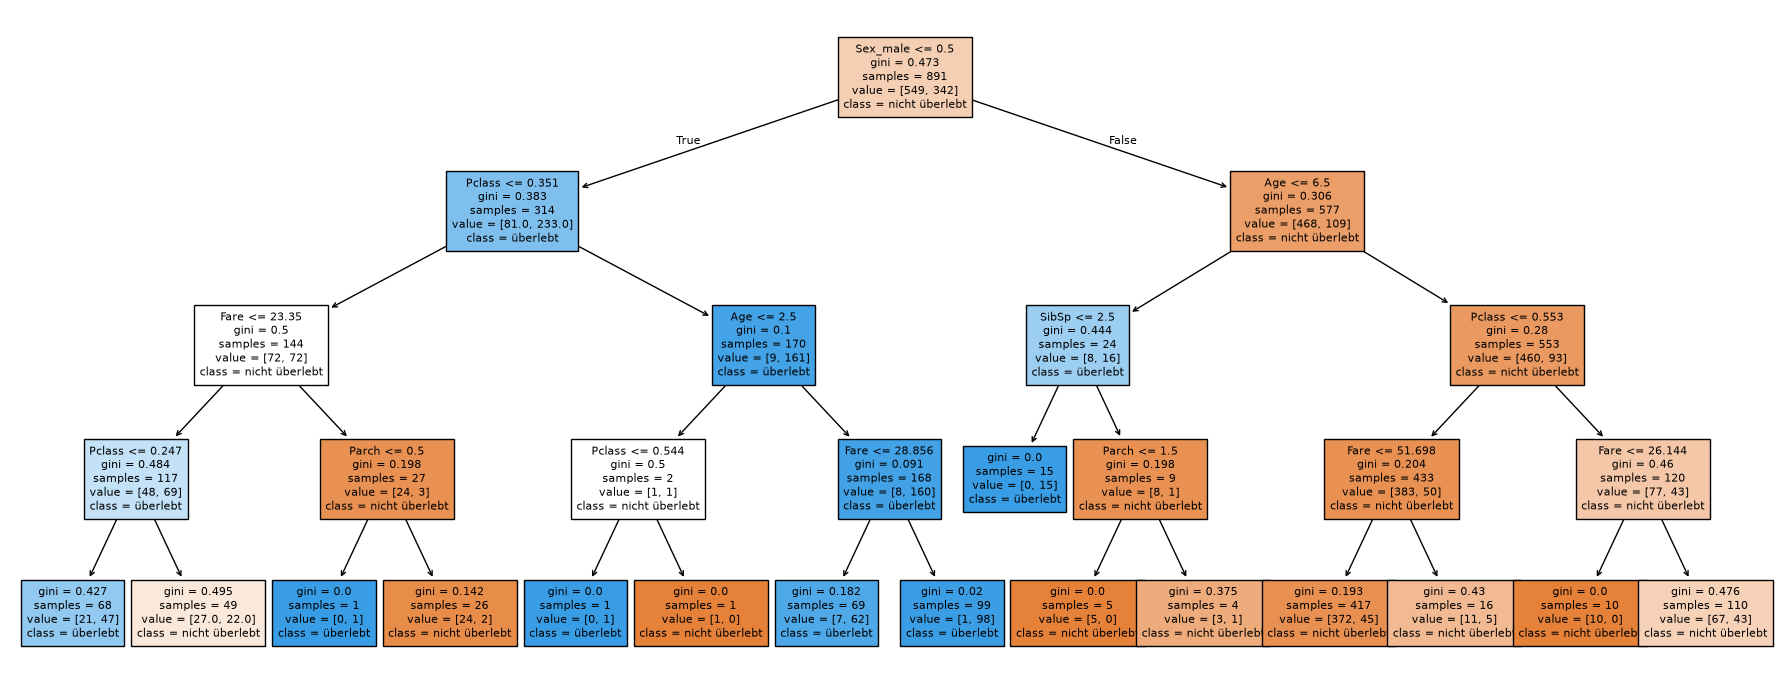

In [ ]:
from sklearn.tree import plot_tree

best_dt = grid_search_dt.best_estimator_

class_names = ['nicht überlebt' if c == 0 else 'überlebt' for c in best_dt.classes_]
plt.figure(figsize=(18, 7))
plot_tree(best_dt, max_depth=4, feature_names=X.columns, class_names=class_names, filled=True, fontsize=8)
plt.tight_layout()
plt.show()

### Lösung

Wir sehen deutlich, dass Muster, dass Frauen und Kinder eher überlebt haben, als Männer. Das ist auch historisch korrekt, da Frauen und Kinder zuerst in die Rettungsboote gelassen wurden. Auch die Passagierklasse spielt eine wichtige Rolle. 

# Aufgabe 3: K-means Clustering in 2D

In dieser Aufgabe werden Sie den k-means Clustering Algorithmus selber zu implementieren. Der Algorithmus teilt eine Punktewolke in $\mathbb{R}^2$ in $k$ Clusters auf.

Wir geben Ihnen zuerst eine Beschreibung des gesamten Algorithmus. Anschliessend implementieren und testen Sie die Schritte einzeln, bevor Sie sie zum Algorithmus zusammenfügen und diesen auf einem Testdatensatz anwenden.

**Clustering Algorithmus**

Inputs: Koordinaten $(x_i, y_i)$ aller Punkte, Anzahl $k$ Clusters.

Am Anfang werden $k$ Punkte zufällig gewählt. Diese dienen als Ausgangswerte für die Schwerpunkte der Clusters.

Nun werden folgende zwei Schritte iterativ ausgeführt:

1. Weise jeden Punkt dem Cluster zu, dessen Schwerpunkt (Centroid) am nächsten liegt.

2. Berechne die Schwerpunkte der Clusters neu (Mittelwert der Koordinaten in jedem Cluster).

Die Iteration wird solange durchgeführt, bis sich die Position der Schwerpunkte nicht mehr ändert.

## a)

Schreiben Sie eine Funktion, die die euklidische Distanz zwischen zwei Punkten berechnet.

In [ ]:
def euclidian_distance(p1, p2):
    '''Calculate the Euclidian distance between two points p1 and p2.'''
    ... # Ihr Code

### Lösung

In [29]:
def euclidian_distance(p1, p2):
    '''Calculate the Euclidian distance between two points p1 and p2.'''
    return np.sqrt(np.sum((p1 - p2)**2))

## b)

Implementieren Sie den ersten Schritt der Iteration: Die Zuweisung der Punkte zu Clusters mit gegebenen Schwerpunkten. Sie können das als Funktion schreiben, oder einfach als Codesnippet, das sie nach dem Testen in den Algorithmus kopieren.

Verwenden Sie hier die vordefinierten Arrays `points` und `centroids`, welche die Datenpunkte und die Schwerpunkte der Clusters enthalten. Iterieren Sie durch alle Datenpunkte, finden Sie den nächstgelegenen Schwerpunkt, und speichern Sie den Index dieses Schwerpunktes in einem Array `assignment`.

*Hinweis: Da im Array `assignment` Indizes gespeichert werden, ist es vorteilhaft, den Datentyp der Arrayeinträge als `int` festzulegen (`dtype=int`).*

Zum Überprüfen können sie die Punkte als Scatterplot darstellen, wobei die Farbe jedes Punktes der Zuweisung zum Cluster entspricht.

In [28]:
n_clusters = 2
points = pickle.load(open('Ex14/Ex 14/Data3/testpoints.p', 'rb'))
centroids = pickle.load(open('Ex14/Ex 14/Data3/testcentroids.p', 'rb'))

### Lösung

In [30]:
# Initialisiere Array für die Zuweisungen
assignment = np.zeros(len(points), dtype=int)
for i, p in enumerate(points):
    # Berchne die Distanz zu jedem Schwerpunkt und speichere den Index des nächsten
    min_distance = np.inf
    for j, c in enumerate(centroids):
        distance = euclidian_distance(p, c)
        if distance < min_distance:  # Kleinere Distanz gefunden?
            min_distance = distance
            assignment[i] = j

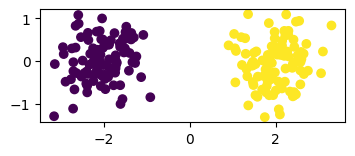

In [ ]:
# Überprüfen
cm = 1 / 2.54
fig = plt.figure(figsize=(10*cm, 10*cm))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(points[:, 0], points[:, 1], c=assignment)
ax.set_aspect(1)

## c)

Implementieren Sie den zweiten Schritt der Iteration: Die Neuberechnung der Schwerpunkte.
    
Verwenden Sie die vordefinierten Arrays `points` und `assignment`. Die Anzahl Cluster ist auch bekannt und in der Variable `n_clusters` gespeichert. Ermitteln Sie den Mittelwert der Koordinaten aller Punkte, die zum gleichen Cluster gehören, wobei x- und y-Koordinaten  separat gemittelt werden. Speichern Sie diese Mittelwerte in `new_centroids`. Sie entsprechen den Koordinaten  der neuen Schwerpunkte.

Zum Überprüfen können Sie wieder die Punkte als Scatterplot darstellen und zusätzlich die Schwerpunkte rot markiert plotten.

<br>
<details>
    <summary><u>Tipp 1 anzeigen</u></summary>
    <br>
    Initialisieren Sie ein Array <code>coord_sum</code> der Grösse <code>(n_clusters, 2)</code>, um die Summe der Koordinaten der Punkte in jedem Cluster zu speichern, und ein Array <code>cluster_size</code> der Grösse <code>(n_clusters)</code>, um die Anzahl Punkte in jedem Cluster zu speichern.
    Iterieren Sie durch die Punkte, um die Koordinaten aufzusummieren und die Grösse der Clusters zu bestimmen.
</details>

<br>
<details>
    <summary><u>Tipp 2 anzeigen</u></summary>
    <br>
    <b>Methode 1</b>: Ein äusserer for-Loop mit Laufvariable <code>k</code> iteriert durch alle Clusters. Ein innerer for-Loop iteriert durch alle Punkte. Bei jedem Punkt prüfen Sie, ob er im <code>k</code>-ten Cluster ist, und falls ja addieren Sie seine Koordinaten zu <code>coord_sum[k]</code> und erhöhen <code>n_clusters[k]</code> um 1. <br>
    <b>Methode 2</b>: Nur ein for-Loop, der durch alle Punkte iteriert, Laufvariable <code>i</code>. Lesen Sie den Index <code>k</code> des Clusters, in dem der <code>i</code>-te Punkt liegt, aus dem Array <code>assignment</code>. Addieren Sie die Koordinaten des <code>i</code>-ten Punktes zu <code>coord_sum[k]</code> und erhöhen Sie <code>n_clusters[k]</code> um 1. <br><br>
    Bilden Sie aus <code>coord_sum</code> und <code>cluster_size</code> den Mittelwert der Koordinaten jedes Clusters und speichern Sie diese im Array <code>new_centroids</code>.
</details>

In [31]:
n_clusters = 2
points = pickle.load(open('Ex14/Ex 14/Data3/testpoints.p', 'rb'))
assignment = pickle.load(open('Ex14/Ex 14/Data3/testassignment.p', 'rb'))

### Lösung

In [32]:
# Array zum Speichern der Anzahl Punkte in jedem Cluster
cluster_size = np.zeros(n_clusters)

# Array zum Speichern der summierten Koordinaten
coord_sum = np.zeros(shape=(n_clusters, 2))

for i, p in enumerate(points):
    # Zum Punkt zugehörigen Cluster auswählen
    cluster_ind = assignment[i]

    # Koordinaten des Punktes zur Summe addieren, Grösse des Clusters um eins erhöhen.
    coord_sum[cluster_ind] += p
    cluster_size[cluster_ind] += 1

# Jede der Koordinatensummen wird durch die entsprechende Clustergrösse dividiert -> Mittelwert
new_centroids = np.zeros(shape=(n_clusters, 2))
for j in range(len(new_centroids)):
    new_centroids[j] = coord_sum[j] / (cluster_size[j] + 1e-9)

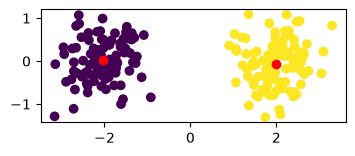

In [ ]:
# Überprüfen
cm = 1 / 2.54
fig = plt.figure(figsize=(10*cm, 10*cm))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(points[:, 0], points[:, 1], c=assignment)
ax.scatter(new_centroids[:, 0], new_centroids[:, 1], c='r')
ax.set_aspect(1)

## d)

Setzen Sie nun die zwei Schritte zum iterativen Algorithmus zusammen. Schreiben Sie hierzu eine Funktion, die folgende Argumente nimmt:

- `points`: Das Array mit den Datenpunkten.
- `n_clusters`: Ein Integer mit der Anzahl Clusters, in die die Punkte eingeteilt werden sollen.
- `tol`: Eine absolute Toleranz für die Abbruchbedingung (siehe unten).
- `max_iterations`: Ein Integer, das angibt, nach wie vielen Durchgängen die Iteration spätestens abgebrochen wird.

Für die Initialisierung erstellen sie ein Zufallsgenerator-Objekt mit `rng = np.random.default_rng()` und verwenden dessen Funktion `rng.choice()` um zufällige Punkte aus dem Datensatz zu wählen.

Die zwei Schritten kommen dann in eine `while`-Schleife mit folgenden Abbruchbedingungen:

- Kein Schwerpunkt hat sich im letzten Durchlauf um mehr als `tol` verschoben, **oder**
- Die Anzahl Durchläufe ist grösser als `max_iterations`.

Am Ende gibt die Funktion die Arrays `assignment` und `centroids` aus, die die Zuweisung der Punkte zu Clusters und die Schwerpunkte der Clusters enthalten.

Testen Sie Ihren Code am Datensatz 'Data3/xy_dataset.txt'. Sie können mit `sklearn.datasets.make_blobs(centers=n_clusters)` auch eigene Datensätze mit mehr oder weniger Clusters generieren. Wenn Sie die Zwischenresultate des Algorithmus anschauen wollen, können Sie `max_iterations` auf 1, 2, 3, etc. setzen und das Resultat plotten.

Extrabonus: Verallgemeinern Sie den Algorithmus für Punkte in $\mathbb{R}^n$.

In [ ]:
from sklearn.datasets import make_blobs

### Lösung

In [ ]:
def euclidian_distance(p1, p2):
    '''Calculate the Euclidian distance between two points p1 and p2.'''
    return np.sqrt(np.sum((p1 - p2)**2))


def k_means(points, n_clusters=3, tol=1e-3, max_iterations=100):
    '''Assign points in M-D space to n_clusters different clusters.
    Args:
        points (Array): 2D-Array with shape (N, M) containing N datapoints points in M-D space.
        n_clusters (int): Number of clusters
        tol (float): tolerance for centroid update to stop the iteration.
                     Iteration stops when the sum of distances between new
                     and old centroid locations is smaller than tol.
        max_iterations (int): Maximum iterations stop condition
        
    Returns:
        assignment: 1D-Array of length N with the assignment for each point to a cluster.
                    Assignment corresponds to index in centroids array.
        centroids: 2D-Array with shape (n_clusters, M) giving the final centroid locations.'''
    
    # Find dimensionality of points
    dim = points.shape[1]
    
    # Inital centroids are chosen randomly from dataset.
    # np.random.seed(1)  # optional fixed seed for reproducible RNG
    rng = np.random.default_rng()
    centroids = rng.choice(points, n_clusters, replace=False)
    
    # Initialize a list that stores the assigment of points to centroids
    assignment = np.zeros(len(points), dtype=int)
    
    # Iterate over assignment and centroid recalculation until centroids are not moving anymore
    centroid_shift = np.inf
    num_iter = 0
    while np.max(centroid_shift) > tol and num_iter < max_iterations:
        ## Assignment
        for i, p in enumerate(points):
            # calculate Euclidian distance to each centroid, save the index of the
            # centroid with smallest distance
            min_distance = np.inf
            for j, c in enumerate(centroids):
                distance = euclidian_distance(p, c)
                if distance < min_distance:
                    min_distance = distance
                    assignment[i] = j
        
        ## Recalculate centroids as means of each cluster
        # Array that stores number of points in each cluster
        cluster_size = np.zeros(n_clusters)
        
        # Array that stores sum of the coordinates of the points in each cluster
        # Used to calculate the mean of the coordinates -> new centroids
        coord_sum = np.zeros(shape=(n_clusters, dim))
        
        for i, p in enumerate(points):
            # Select assigned cluster
            cluster_ind = assignment[i]
            
            # Add x and y coordinates centroid coordinates, increase number of points in cluster by 1
            coord_sum[cluster_ind] += p
            cluster_size[cluster_ind] += 1
        
        # Divide each of the coord_sum by the corresponding cluster_size
        # -> we have calculated the mean of the x and y coordinates of all points in each cluster
        new_centroids = np.zeros(shape=(n_clusters, dim))
        for j in range(len(new_centroids)):
            new_centroids[j] = coord_sum[j] / (cluster_size[j] + 1e-9)
        
        # calculate the total shift
        centroid_shift = np.zeros(n_clusters)
        for j in range(len(new_centroids)):
            centroid_shift[j] = euclidian_distance(centroids[j], new_centroids[j])  # Norm of the vector
            
        # Update centroids and number of iterations
        centroids = np.copy(new_centroids)
        num_iter += 1
    
    # End while
    
    if num_iter >= max_iterations - 1:
        print('Warning: maximum iterations reached. Result might not be converged.')
    
    # Return assigments
    return assignment, centroids

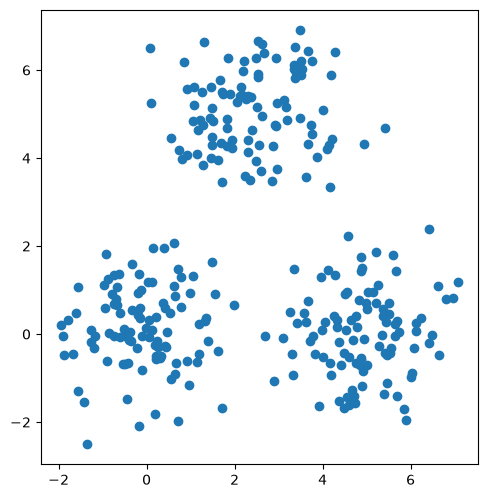

In [ ]:
# Daten Laden und Plotten
points = np.loadtxt('Ex14/Ex 14/Data3/xy_dataset.txt')

cm = 1 / 2.54
fig = plt.figure(figsize=(15*cm, 15*cm))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(points[:, 0], points[:, 1])
ax.set_aspect(1)

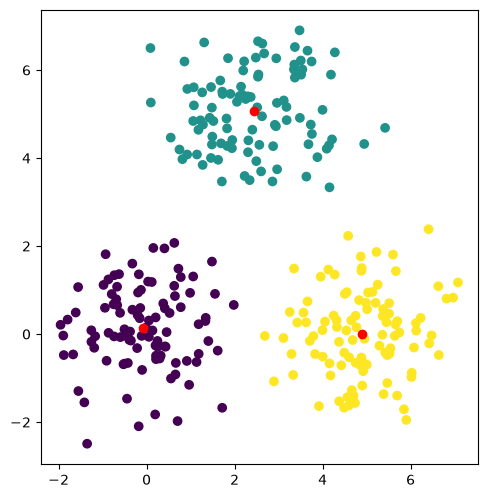

In [ ]:
# k-means Clustering anwenden, Resultat plotten
assignment, centroids = k_means(points, n_clusters=3, max_iterations=10)

cm = 1 / 2.54
fig = plt.figure(figsize=(15*cm, 15*cm))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(points[:, 0], points[:, 1], c=assignment)
ax.scatter(centroids[:, 0], centroids[:, 1], c='r')
ax.set_aspect(1)

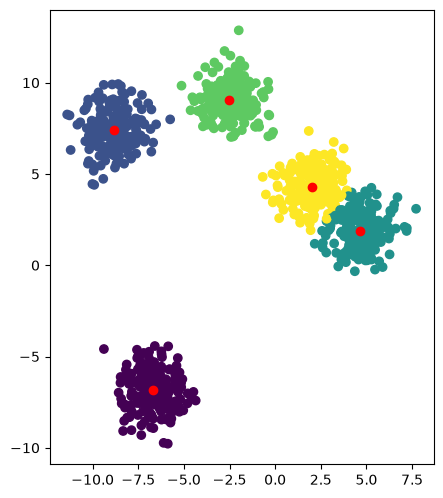

In [ ]:
# Eigene Datensätze generieren und Resultat plotten
n_clusters = 5
points, _ = make_blobs(centers=n_clusters, n_samples=1000, random_state = 42)

assignment, centroids = k_means(points, n_clusters=n_clusters, max_iterations=100)

cm = 1 / 2.54
fig = plt.figure(figsize=(15*cm, 15*cm))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(points[:, 0], points[:, 1], c=assignment)
ax.scatter(centroids[:, 0], centroids[:, 1], c='r')
ax.set_aspect(1)

Wenn Sie einige zufällige Datensätze ausprobieren, werden Sie sehen, dass der Algorithmus die Cluster nicht immer korrekt identifizieren kann. Das liegt an der zufälligen Initialisierung und daran, dass der Algorithmus relativ simpel ist und sozusagen in lokalen Minima stecken bleiben kann. Allerdings ist die Konvergenz erstaunlich schnell, meistens braucht es nur 4 oder 5 Iterationen, um zum Resultat zu gelangen.